# Proejto de Redes Neurais

Alunos:
- Hugo Andrade
- Jessica Maria
- Vinícius Ribeiro

---
Ultilizamos, para a primeira iteração, um modelo preditivo MLP de 7 dias (7 saidas), **uma camada escondida com 20 neurônios**, empregando a função de ativação **ReLU (Rectified Linear Unit)**.

Após isso, fizemos a combinação do solicitado pelo professor, para teste e comparação:

```python
# --- Hiperparâmetros variaveis, à testar (conforme enunciado do prof) ---
window_in_list = [15, 30, 45] #dias de entrada
hidden_layers_list = [1, 2]
neurons_list = [20, 40, 60] # neurons na hidden
optimizers_map = {        # Funções de otimização
    'RMSprop': RMSprop,
    'Adagrad': Adagrad
}

# --- Valores Fixos ---
window_out = 7  # dias a frente
max_epochs = 200  # Epocas

```

A **taxa de aprendizado é de 0.001**, e a **função de perda MSE (Mean Squared Error)**.

A normalização dos dados foi realizada com base na média e desvio padrão do conjunto de treinamento.

 O processo de aprendizado utilizou **dados históricos até o ano de 2010** para treino e validação, enquanto o intervalo de **2011 a 2016** foi para testes.

 Usamos **Erro Médio Absoluto (MAE)**, aplicado no conjunto de teste.




## 1 — Bibliotecas

In [ ]:
# === 1. Bibliotecas ===

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# Reprodutibilidade
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)


## 2 — Carregamento dos dados (CSV do Drive)

In [ ]:
# === 2. Carregamento dos dados ===

# URL de download direto do Google Drive
url = "https://drive.google.com/uc?export=download&id=1JMALdp_zahSRRPaIkNGHYohlTmntmXLj"

df = pd.read_csv(url, sep=",", header=0, names=["Data", "Vazao"])

print(df)

# Converter datas e limpar
df["Data"] = pd.to_datetime(df["Data"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["Data", "Vazao"])
df = df[pd.to_numeric(df["Vazao"], errors="coerce").notnull()]
df["Vazao"] = df["Vazao"].astype(float)
df = df.sort_values("Data")
df["Ano"] = df["Data"].dt.year

print("Amostras totais:", len(df))
df.head()


              Data  Vazao
0       1/jan/1931  16060
1       2/jan/1931  15935
2       3/jan/1931  15559
3       4/jan/1931  15309
4       5/jan/1931  15109
...            ...    ...
31407  27/dez/2016   5832
31408  28/dez/2016   5520
31409  29/dez/2016   5255
31410  30/dez/2016   5114
31411  31/dez/2016   5052

[31412 rows x 2 columns]


/tmp/ipython-input-3841540915.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Data"] = pd.to_datetime(df["Data"], dayfirst=True, errors="coerce")


Amostras totais: 13158


,Data,Vazao,Ano
0,1931-01-01,16060.0,1931
1,1931-01-02,15935.0,1931
2,1931-01-03,15559.0,1931
3,1931-01-04,15309.0,1931
4,1931-01-05,15109.0,1931


## 3 — Divisão entre treino e teste

In [ ]:
# === 3. Divisão treino/teste ===

train_data = df[df["Ano"] <= 2010].reset_index(drop=True)
test_data = df[df["Ano"] >= 2011].reset_index(drop=True)

train_values = train_data["Vazao"].values
test_values = test_data["Vazao"].values

print(f"Tamanho treino: {len(train_values)}")
print(f"Tamanho teste: {len(test_values)}")


Tamanho treino: 12240
Tamanho teste: 918


## 4 — Criação das janelas de entrada e saída

In [ ]:
# === 4. Criar janelas ===

window_in = 15  # 15 valores passados
window_out = 7  # 7 valores futuros

X, y = [], []
for i in range(len(train_values) - window_in - window_out + 1):
    X.append(train_values[i : i + window_in])
    y.append(train_values[i + window_in : i + window_in + window_out])

X = np.array(X)
y = np.array(y)

print("Formato X:", X.shape)
print("Formato y:", y.shape)

Formato X: (12219, 15)
Formato y: (12219, 7)


## 5 — **Normalização**

In [ ]:
# === 5. Normalização ===

mean = X.mean()
std = X.std()

X_norm = (X - mean) / std
y_norm = (y - mean) / std

print("Normalização concluída. Média:", mean, "Desvio padrão:", std)

Normalização concluída. Média: 6957.77717216357 Desvio padrão: 4047.4601874484138


## 6 — Definição do modelo

In [ ]:
# === 6. Definição do modelo MLP ===

# ----- Configurações gerais -----
window_in = 15                  # número de entradas (valores passados)
window_out = 7                  # número de saídas (valores futuros)
hidden_layers = 1               # quantidade de camadas ocultas
neurons_hidden = 20             # neurônios na camada oculta
activation_hidden = 'relu'      # Função de ativação usada nas camadas ocultas (ajuda a modelar não-linearidades)
activation_output = None        # Sem ativação na saída (output linear), ideal para problemas de regressão
optimizer_used = 'adam'         # Otimizador que ajusta os pesos da rede (rápido e estável)
learning_rate = 0.001           # Taxa de aprendizado do otimizador (define o tamanho dos passos na atualização)
loss_function = 'mse'           # Função de perda (Erro Quadrático Médio), mede o erro durante o treino
metric_used = 'mae'             # Métrica monitorada (Erro Absoluto Médio), usada para avaliar desempenho


# ----- Modelo -----
model = Sequential([
    Input(shape=(window_in,)),
    Dense(neurons_hidden, activation=activation_hidden),
    Dense(window_out, activation=activation_output)
])

model.compile(
    optimizer=tf.keras.optimizers.get({
        "class_name": optimizer_used,
        "config": {"learning_rate": learning_rate}
    }),
    loss=loss_function,
    metrics=[metric_used]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467 (1.82 KB)

 Trainable params: 467 (1.82 KB)

 Non-trainable params: 0 (0.00 B)

## 7 — Treinamento

In [ ]:
# === 7. Treinamento do modelo ===

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_norm, y_norm,
    epochs=50,   # epocas
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

# Guardar o número total de épocas realmente executadas
num_epochs = len(history.history['loss'])


Epoch 1/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7356 - mae: 0.5509
Epoch 2/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2525 - mae: 0.3162
Epoch 3/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2102 - mae: 0.2740
Epoch 4/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2012 - mae: 0.2638
Epoch 5/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1964 - mae: 0.2581
Epoch 6/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1933 - mae: 0.2540
Epoch 7/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1910 - mae: 0.2509
Epoch 8/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1891 - mae: 0.2487
Epoch 9/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1877 - mae: 0.2469
Epoch 10/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1867 - mae: 0.2455
Epoch 11/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1858 - mae: 0.2445
Epoch 12/50
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1852 - mae: 0.2437
Epoch 13/50
382/382 ━━━━━

## 8 — Preparação dos dados de teste

In [ ]:
# === 8. Preparar dados de teste ===

X_test, y_test = [], []
for i in range(len(test_values) - window_in - window_out + 1):
    X_test.append(test_values[i : i + window_in])
    y_test.append(test_values[i + window_in : i + window_in + window_out])

X_test = np.array(X_test)
y_test = np.array(y_test)

X_test_norm = (X_test - mean) / std
y_test_norm = (y_test - mean) / std

print("Conjunto de teste preparado.")


Conjunto de teste preparado.


## 9 — Previsão e inversão da normalização

In [ ]:
# === 9. Previsões ===

y_pred_norm = model.predict(X_test_norm)

# Reverter normalização
y_pred = y_pred_norm * std + mean
y_true = y_test

print("Previsões concluídas.")

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Previsões concluídas.


## 10 — Avaliação e gráfico

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


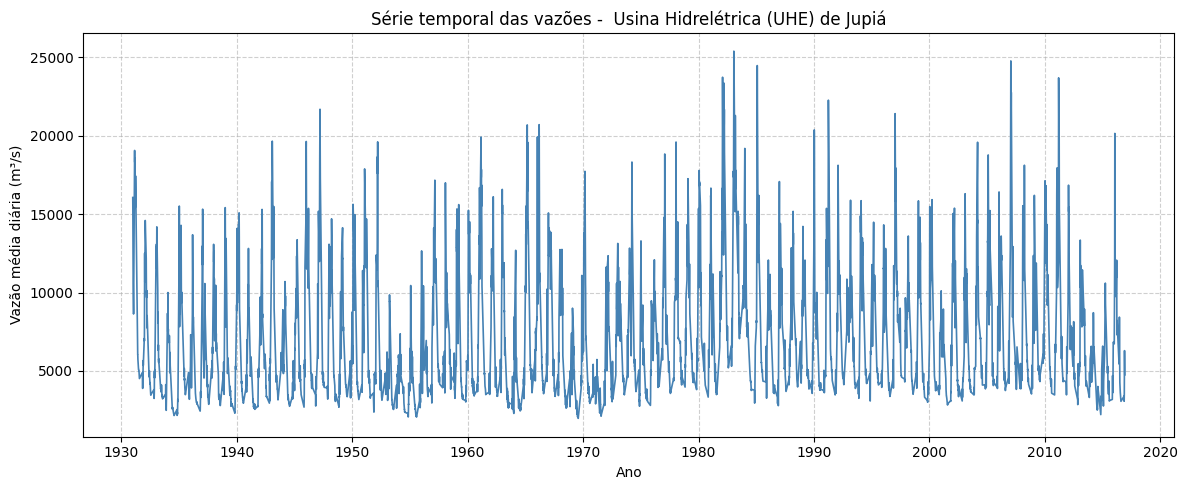

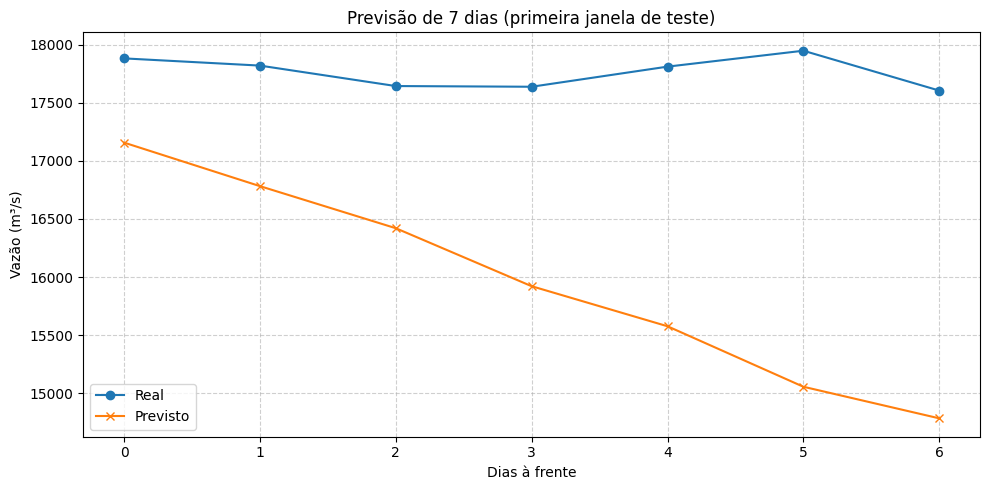

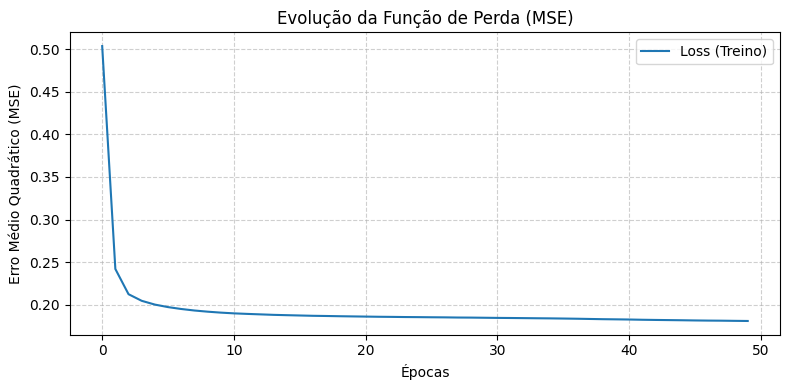



Características do Modelo MLP Utilizado
Camadas de entrada : 15 neurônios (15 valores passados)
Camadas escondidas : 1 camada(s) com 20 neurônios
Função de ativação (oculta): relu
Camada de saída    : 7 neurônios (7 dias futuros)
Função de ativação (saída) : None
Otimização         : adam (learning_rate = 0.001)
Função de perda    : mse
Métrica utilizada  : MAE
------------------------------------------------------------


Dados do Treinamento/Teste
Amostras de treino : 12219
Amostras de teste  : 897
Período de treino  : até 2010
Período de teste   : 2011–2016
Épocas de treinamento: 50
------------------------------------------------------------


Resultados
Erro Médio Absoluto (MAE): 859.13 m³/s
Erro Percentual Médio Absoluto (MAPE): 13.36%
Taxa média de previsão: 86.64%


In [ ]:
# === 10. Avaliação, gráficos e resumo ===

# ---- 1. Avaliação ----
y_pred_norm = model.predict(X_test_norm)
y_pred = y_pred_norm * std + mean
y_true = y_test

mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())

# Cálculo adicional: erro percentual médio absoluto (MAPE) e taxa média de previsão
mape = np.mean(np.abs((y_true.flatten() - y_pred.flatten()) / y_true.flatten())) * 100  # em %
taxa_previsao = 100 - mape  # taxa de acerto aproximada (%)

# ---- 2. Gráfico geral da série de vazões ----
plt.figure(figsize=(12,5))
plt.plot(df["Data"], df["Vazao"], color='steelblue', linewidth=1.2)
plt.title("Série temporal das vazões -  Usina Hidrelétrica (UHE) de Jupiá")
plt.xlabel("Ano")
plt.ylabel("Vazão média diária (m³/s)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ---- 3. Gráfico da previsão (primeira janela do teste) ----
plt.figure(figsize=(10,5))
plt.plot(y_true[0], label='Real', marker='o')
plt.plot(y_pred[0], label='Previsto', marker='x')
plt.title("Previsão de 7 dias (primeira janela de teste)")
plt.xlabel("Dias à frente")
plt.ylabel("Vazão (m³/s)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ---- 4. Gráfico da evolução da função de perda ----
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Loss (Treino)', linewidth=1.5)
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Loss (Validação)', linewidth=1.5)
plt.title("Evolução da Função de Perda (MSE)")
plt.xlabel("Épocas")
plt.ylabel("Erro Médio Quadrático (MSE)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ---- 5. Exibição dos resultados numéricos e configuração da rede ----
print("="*60)
print("\n\nCaracterísticas do Modelo MLP Utilizado")
print("="*60)
print(f"Camadas de entrada : {window_in} neurônios ({window_in} valores passados)")
print(f"Camadas escondidas : {hidden_layers} camada(s) com {neurons_hidden} neurônios")
print(f"Função de ativação (oculta): {activation_hidden}")
print(f"Camada de saída    : {window_out} neurônios ({window_out} dias futuros)")
print(f"Função de ativação (saída) : {activation_output}")
print(f"Otimização         : {optimizer_used} (learning_rate = {learning_rate})")
print(f"Função de perda    : {loss_function}")
print(f"Métrica utilizada  : {metric_used.upper()}")
print("-"*60)
print("\n\nDados do Treinamento/Teste")
print(f"Amostras de treino : {len(X)}")
print(f"Amostras de teste  : {len(X_test)}")
print(f"Período de treino  : até 2010")
print(f"Período de teste   : 2011–2016")
print(f"Épocas de treinamento: {num_epochs}")
print("-"*60)
print("\n\nResultados")
print(f"Erro Médio Absoluto (MAE): {mae:.2f} m³/s")
print(f"Erro Percentual Médio Absoluto (MAPE): {mape:.2f}%")
print(f"Taxa média de previsão: {taxa_previsao:.2f}%")
print("="*60)


# 11 - Comparações graficas

Run 1/36 — window_in=15, hidden_layers=1, neurons=20, optimizer=RMSprop
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
  -> done (epochs=200)  MAE=850.254  MAPE=13.46%  time=175.0s
Run 2/36 — window_in=15, hidden_layers=1, neurons=20, optimizer=Adagrad
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
  -> done (epochs=200)  MAE=1092.791  MAPE=16.79%  time=170.1s
Run 3/36 — window_in=15, hidden_layers=1, neurons=40, optimizer=RMSprop
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
  -> done (epochs=200)  MAE=820.448  MAPE=13.02%  time=171.3s
Run 4/36 — window_in=15, hidden_layers=1, neurons=40, optimizer=Adagrad
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
  -> done (epochs=200)  MAE=1002.756  MAPE=15.61%  time=171.6s
Run 5/36 — window_in=15, hidden_layers=1, neurons=60, optimizer=RMSprop
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
  -> done (epochs=200)  MAE=835.785  MAPE=13.36%  time=171.4s
Run 6/36 — window_in=15, hidden_layers=1, neurons=60, optimizer=Adagrad
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
  -> done (epochs=200

,window_in,hidden_layers,neurons,optimizer,epochs,mae,mape
0,15,1,40,RMSprop,200,820.447980,13.016873
1,15,2,20,RMSprop,200,820.633154,13.058993
2,30,2,20,RMSprop,200,863.998689,13.149984
3,15,1,60,RMSprop,200,835.785388,13.358104
4,15,1,20,RMSprop,200,850.253712,13.464123
5,15,2,40,RMSprop,200,891.816580,14.061671
6,30,1,40,RMSprop,200,897.189657,14.114061
7,15,2,60,Adagrad,200,924.147964,14.260450
8,45,1,20,RMSprop,200,830.827736,14.312187
9,30,1,20,RMSprop,200,907.378602,14.345205



Top 3 combinações (menor MAPE):
   window_in  hidden_layers  neurons optimizer  epochs         mae       mape
0         15              1       40   RMSprop     200  820.447980  13.016873
1         15              2       20   RMSprop     200  820.633154  13.058993
2         30              2       20   RMSprop     200  863.998689  13.149984

Melhor configuração encontrada:
window_in=15, hidden_layers=1, neurons=40, optimizer=RMSprop, epochs=200
MAE=820.448, MAPE=13.02%


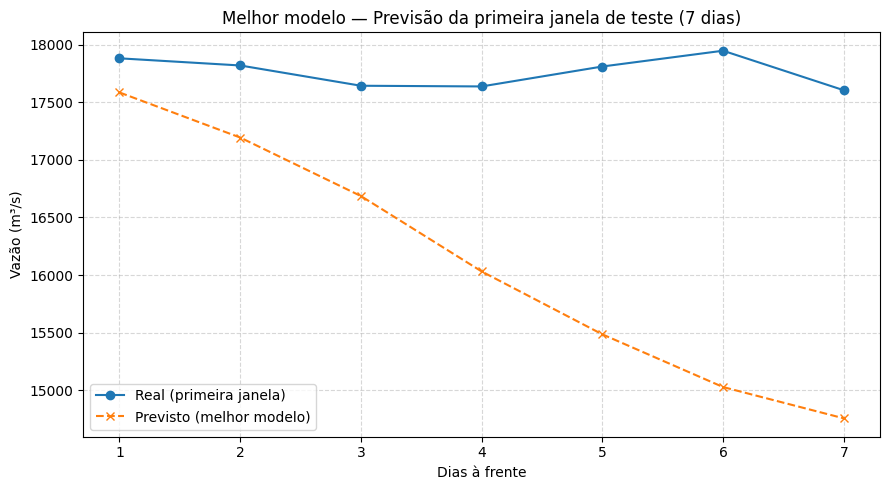

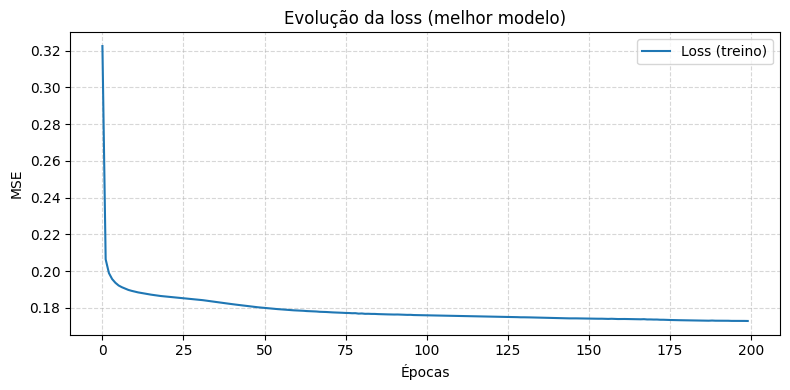

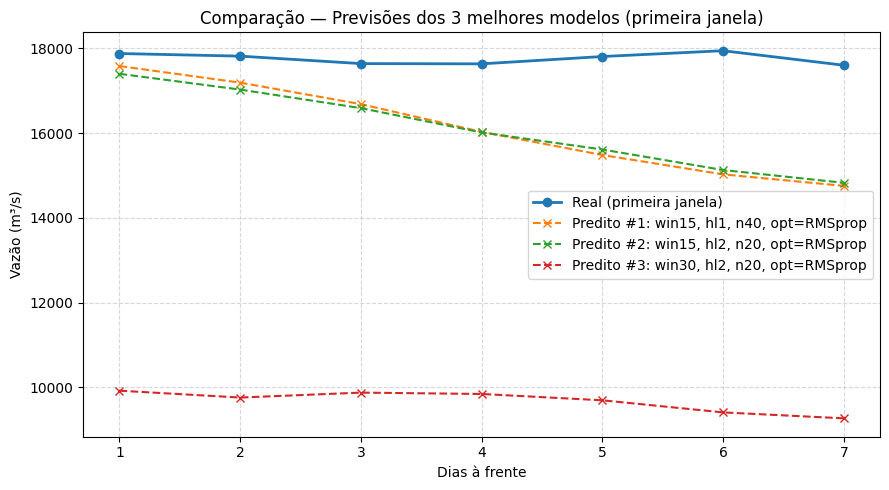

,rank,window_in,hidden_layers,neurons,optimizer,epochs,mae,mape
0,1,15,1,40,RMSprop,200,820.447980,13.016873
1,2,15,2,20,RMSprop,200,820.633154,13.058993
2,3,30,2,20,RMSprop,200,863.998689,13.149984



CUIDADO: por memória, os objetos 'model' foram mantidos em 'best_infos' — se você fizer muitos experimentos, pode esgotar RAM. Remova objetos se necessário com tf.keras.backend.clear_session().


In [ ]:
# === 11 — Grid search conforme especificações do professor ===
import itertools
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import RMSprop, Adagrad

# Garantir reprodutibilidade razoável entre runs
seed_value = 42
import os
os.environ['PYTHONHASHSEED'] = str(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# --- Hiperparâmetros a testar (conforme enunciado do prof) ---
window_in_list = [15, 30, 45]
hidden_layers_list = [1, 2]
neurons_list = [20, 40, 60]
optimizers_map = {
    'RMSprop': RMSprop,
    'Adagrad': Adagrad
}

# Training settings
window_out = 7
max_epochs = 200
batch_size = 32
earlystop_patience = 10
verbose_fit = 0  # 0 para não poluir o notebook; mude para 1 se preferir ver o treino

# Small epsilon to avoid division by zero in MAPE
eps = 1e-8

# Prepare container for results
results = []

# We'll keep best models' info and predictions for final plotting
top_models_info = []

# Access train_values and test_values already present in notebook
# If not present, recompute from df:
try:
    train_values
    test_values
except NameError:
    # Recompute partitions as in your notebook (uses df with "Ano" column)
    train_data = df[df["Ano"] <= 2010].reset_index(drop=True)
    test_data = df[df["Ano"] >= 2011].reset_index(drop=True)
    train_values = train_data["Vazao"].values
    test_values = test_data["Vazao"].values

# Function to build an MLP according to params
def build_mlp(window_in, window_out, hidden_layers, neurons, activation_hidden='relu', activation_output=None, optimizer=None):
    model = Sequential()
    model.add(Input(shape=(window_in,)))
    # Add first hidden layer
    model.add(Dense(neurons, activation=activation_hidden))
    # Add second hidden layer if requested
    if hidden_layers == 2:
        model.add(Dense(neurons, activation=activation_hidden))
    # Output layer
    model.add(Dense(window_out, activation=activation_output))
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# Iterate over all combinations
total_runs = len(window_in_list) * len(hidden_layers_list) * len(neurons_list) * len(optimizers_map)
run_idx = 0
start_time_all = time.time()

for (window_in, hidden_layers, neurons, opt_name) in itertools.product(window_in_list, hidden_layers_list, neurons_list, optimizers_map.keys()):
    run_idx += 1
    print(f"Run {run_idx}/{total_runs} — window_in={window_in}, hidden_layers={hidden_layers}, neurons={neurons}, optimizer={opt_name}")
    start_time = time.time()

    # Create train windows
    X_train, y_train = [], []
    for i in range(len(train_values) - window_in - window_out + 1):
        X_train.append(train_values[i : i + window_in])
        y_train.append(train_values[i + window_in : i + window_in + window_out])
    X_train = np.array(X_train)
    y_train = np.array(y_train)

    # Normalize based on train set (como no seu notebook)
    mean_train = X_train.mean()
    std_train = X_train.std()
    X_train_norm = (X_train - mean_train) / (std_train + eps)
    y_train_norm = (y_train - mean_train) / (std_train + eps)

    # Create test windows for this window_in
    X_test_local, y_test_local = [], []
    for i in range(len(test_values) - window_in - window_out + 1):
        X_test_local.append(test_values[i : i + window_in])
        y_test_local.append(test_values[i + window_in : i + window_in + window_out])
    X_test_local = np.array(X_test_local)
    y_test_local = np.array(y_test_local)
    X_test_norm_local = (X_test_local - mean_train) / (std_train + eps)
    y_test_norm_local = (y_test_local - mean_train) / (std_train + eps)

    # Build optimizer instance with chosen learning rate default
    OptimClass = optimizers_map[opt_name]
    optimizer_instance = OptimClass()  # usa padrão; se quiser lr custom, passar config aqui

    # Clear previous model from memory/session
    tf.keras.backend.clear_session()
    model = build_mlp(window_in, window_out, hidden_layers, neurons, optimizer=optimizer_instance)

    # Early stopping
    early_stop = EarlyStopping(monitor='loss', patience=earlystop_patience, restore_best_weights=True, verbose=0)

    # Fit
    history = model.fit(
        X_train_norm, y_train_norm,
        epochs=max_epochs,
        batch_size=batch_size,
        verbose=verbose_fit,
        callbacks=[early_stop]
    )

    # Number of epochs used
    epochs_ran = len(history.history['loss'])

    # Predict on test set and invert normalization
    y_pred_norm_local = model.predict(X_test_norm_local)
    y_pred_local = y_pred_norm_local * (std_train + eps) + mean_train
    y_true_local = y_test_local

    # Metrics: MAE and MAPE (EPMA)
    mae = mean_absolute_error(y_true_local.flatten(), y_pred_local.flatten())
    # MAPE: ignore positions where true = 0 (or add eps)
    mape = np.mean(np.abs((y_true_local.flatten() - y_pred_local.flatten()) / (np.abs(y_true_local.flatten()) + eps))) * 100.0

    # Save summary
    results.append({
        'window_in': window_in,
        'hidden_layers': hidden_layers,
        'neurons': neurons,
        'optimizer': opt_name,
        'epochs': epochs_ran,
        'mae': mae,
        'mape': mape
    })

    # Keep top predictions for later comparison (we'll store first-window prediction)
    # First test window predicted vs true
    if len(y_true_local) > 0:
        first_true = y_true_local[0]         # shape (7,)
        first_pred = y_pred_local[0].flatten()
    else:
        first_true = np.array([np.nan]*window_out)
        first_pred = np.array([np.nan]*window_out)

    top_models_info.append({
        'window_in': window_in,
        'hidden_layers': hidden_layers,
        'neurons': neurons,
        'optimizer': opt_name,
        'epochs': epochs_ran,
        'mae': mae,
        'mape': mape,
        'first_true': first_true,
        'first_pred': first_pred,
        'model': model,  # keep model for the best later (careful with memory)
        'mean_train': mean_train,
        'std_train': std_train,
        'history': history
    })

    elapsed = time.time() - start_time
    print(f"  -> done (epochs={epochs_ran})  MAE={mae:.3f}  MAPE={mape:.2f}%  time={elapsed:.1f}s")

elapsed_all = time.time() - start_time_all
print(f"\nAll runs finished in {elapsed_all:.1f}s")

# --- Results DataFrame ---
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('mape', ascending=True).reset_index(drop=True)
display(results_df)

# --- Selecionar 3 melhores pelos mape ---
top3 = results_df.head(3)
print("\nTop 3 combinações (menor MAPE):")
print(top3)

# Encontrar os objetos em top_models_info correspondentes aos top3
# (procura por igualdade de parâmetros)
best_infos = []
for idx, row in top3.iterrows():
    for info in top_models_info:
        if (info['window_in'] == int(row['window_in']) and
            info['hidden_layers'] == int(row['hidden_layers']) and
            info['neurons'] == int(row['neurons']) and
            info['optimizer'] == row['optimizer'] and
            abs(info['mape'] - row['mape']) < 1e-6):
            best_infos.append(info)
            break

# Se por acaso houver duplicatas ou falta, garantir que temos até 3
best_infos = best_infos[:3]

# --- Plot do MELHOR modelo (detalhado) ---
best = best_infos[0]
print("\nMelhor configuração encontrada:")
print(f"window_in={best['window_in']}, hidden_layers={best['hidden_layers']}, neurons={best['neurons']}, optimizer={best['optimizer']}, epochs={best['epochs']}")
print(f"MAE={best['mae']:.3f}, MAPE={best['mape']:.2f}%")

# Plot: previsão da primeira janela (7 dias) para o melhor modelo
plt.figure(figsize=(9,5))
x_axis = np.arange(1, window_out+1)
plt.plot(x_axis, best['first_true'], marker='o', linestyle='-', label='Real (primeira janela)')
plt.plot(x_axis, best['first_pred'], marker='x', linestyle='--', label='Previsto (melhor modelo)')
plt.title("Melhor modelo — Previsão da primeira janela de teste (7 dias)")
plt.xlabel("Dias à frente")
plt.ylabel("Vazão (m³/s)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Plot da loss do melhor modelo (treino)
plt.figure(figsize=(8,4))
plt.plot(best['history'].history['loss'], label='Loss (treino)')
plt.title("Evolução da loss (melhor modelo)")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# --- Comparação: 3 melhores no mesmo plot (previsão da primeira janela) ---
plt.figure(figsize=(9,5))
plt.plot(x_axis, best['first_true'], marker='o', linestyle='-', label='Real (primeira janela)', linewidth=2)
colors = ['tab:blue','tab:orange','tab:green']
for i, info in enumerate(best_infos):
    plt.plot(x_axis, info['first_pred'], marker='x', linestyle='--', label=f"Predito #{i+1}: win{info['window_in']}, hl{info['hidden_layers']}, n{info['neurons']}, opt={info['optimizer']}")
plt.title("Comparação — Previsões dos 3 melhores modelos (primeira janela)")
plt.xlabel("Dias à frente")
plt.ylabel("Vazão (m³/s)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# --- Exibir tabela resumida dos 3 melhores ---
top3_display = results_df.head(3).copy()
top3_display['rank'] = [1,2,3]
display(top3_display[['rank','window_in','hidden_layers','neurons','optimizer','epochs','mae','mape']])

print("\nCUIDADO: por memória, os objetos 'model' foram mantidos em 'best_infos' — se você fizer muitos experimentos, pode esgotar RAM. Remova objetos se necessário com tf.keras.backend.clear_session().")
